Predictive Maintenance for Industrial Equipment using Machine Learning

Unexpected equipment failures (e.g., robot equipment failure) can cause significant operational disruptions in manufacturing environments, including costly downtime, delayed production, and expensive emergency repairs. Traditional maintenance strategies often rely on scheduled servicing or reactive repairs after failures occur, which may either waste resources or fail to prevent unexpected breakdowns.

This project develops a predictive maintenance system using machine learning to estimate the Remaining Useful Life (RUL) of equipment based on sensor data. By analyzing historical operational signals, the model can anticipate degradation patterns and provide early warnings of potential failures.

Using the NASA C-MAPSS turbofan engine degradation dataset, the project demonstrates how predictive maintenance models can:

- estimate the remaining operational life of industrial systems,
- detect when equipment is approaching failure,
- and support proactive maintenance scheduling.

The modeling pipeline includes:

- feature engineering using rolling statistics from sensor signals,
- baseline and advanced machine learning models,
- a sequence-based LSTM deep learning model for time-series prediction,
- a failure risk classifier that identifies machines likely to fail soon,
- and a cost-based decision policy that translates predictions into maintenance actions.

The final system demonstrates how predictive analytics can reduce downtime risk and improve operational efficiency in automated industrial environments such as robotics, manufacturing systems, and smart factories.

In [62]:
# ============================================================
# Predictive Maintenance (NASA C-MAPSS FD001)
# End-to-end Colab notebook code
# ============================================================

!pip -q install scikit-learn pandas numpy matplotlib joblib
!pip -q install tensorflow

import os, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib


This notebook builds a predictive maintenance pipeline using the NASA C-MAPSS dataset. We will (1) predict Remaining Useful Life (RUL) and (2) produce a “fail soon” risk score (e.g., failure within 30 cycles).

# Download + Load Data

In [63]:
zip_candidates = [
    "/content/archive.zip",
    "/mnt/data/archive.zip"   # this chat environment
]

zip_path = next((p for p in zip_candidates if os.path.exists(p)), None)
if zip_path is None:
    raise FileNotFoundError("Could not find archive.zip in /content or /mnt/data. Upload it to Colab and try again.")

extract_dir = "/content/CMAPSS"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extracted to:", extract_dir)
print("Top-level contents:", os.listdir(extract_dir)[:10])

Extracted to: /content/CMAPSS
Top-level contents: ['CMaps']


We load the Kaggle zip locally (no external download). The extracted folder contains the C-MAPSS train/test files for FD001–FD004.

# Load FD001

In [64]:
# Paths inside the zip: CMAPSS/CMaps/*.txt
data_folder = os.path.join(extract_dir, "CMaps")

train_path = os.path.join(data_folder, "train_FD001.txt")
test_path  = os.path.join(data_folder, "test_FD001.txt")
rul_path   = os.path.join(data_folder, "RUL_FD001.txt")

# Column names (unit, cycle, 3 operating settings, 21 sensors)
col_names = ["unit", "cycle",
             "op_setting_1", "op_setting_2", "op_setting_3"] + \
            [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None)
test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None)
rul_df   = pd.read_csv(rul_path,   sep=r"\s+", header=None)

# Drop extra empty columns (some versions include trailing spaces)
train_df = train_df.iloc[:, :len(col_names)]
test_df  = test_df.iloc[:, :len(col_names)]

train_df.columns = col_names
test_df.columns  = col_names
rul_df.columns   = ["RUL_last_cycle"]

train_df.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


We start with FD001 because it has a single operating condition and is the cleanest benchmark. Each unit is a machine/engine observed across cycles with multiple sensor readings

# Create RUL Labels (Train + Test)

In [65]:
# --- Train RUL: RUL = max_cycle(unit) - cycle
train_max = train_df.groupby("unit")["cycle"].max().reset_index()
train_max.columns = ["unit", "max_cycle"]

train_df = train_df.merge(train_max, on="unit", how="left")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df.drop(columns=["max_cycle"], inplace=True)

# --- Test RUL per cycle:
# NASA provides RUL at the last observed cycle for each unit (rul_df).
test_max = test_df.groupby("unit")["cycle"].max().reset_index()
test_max.columns = ["unit", "max_cycle"]
test_df = test_df.merge(test_max, on="unit", how="left")

# Merge RUL_last_cycle by unit index (units are 1..N in order)
rul_df = rul_df.copy()
rul_df["unit"] = np.arange(1, len(rul_df) + 1)

test_df = test_df.merge(rul_df, on="unit", how="left")
test_df["RUL"] = (test_df["max_cycle"] + test_df["RUL_last_cycle"]) - test_df["cycle"]
test_df.drop(columns=["max_cycle"], inplace=True)

train_df[["unit", "cycle", "RUL"]].head()

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


We converted the dataset into a supervised learning problem by constructing Remaining Useful Life (RUL). In training data, failure occurs at the final cycle, so RUL is computed exactly. For the test set, NASA provides the true RUL at the last observed cycle.

# EDA: Degradation Patterns in Sensors (visual proof of signal)

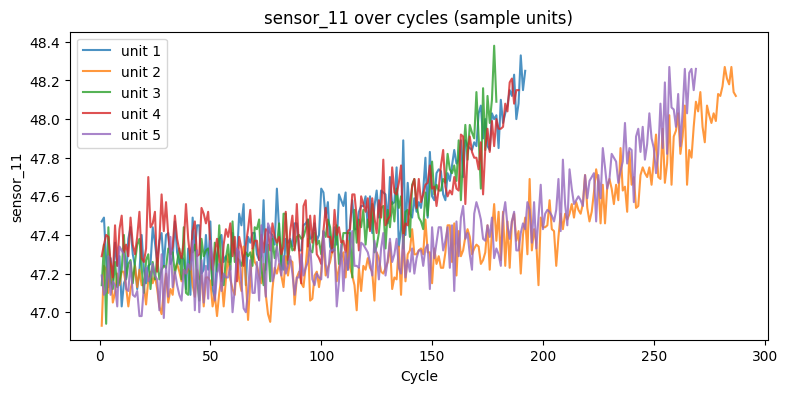

In [66]:
# --- EDA: Visualize sensor behavior over lifecycle for a few units ---
units_to_plot = train_df["unit"].unique()[:5]
sensor_to_plot = "sensor_11"  # change if you want

plt.figure(figsize=(9,4))
for u in units_to_plot:
    d = train_df[train_df["unit"] == u].sort_values("cycle")
    plt.plot(d["cycle"], d[sensor_to_plot], alpha=0.8, label=f"unit {u}")
plt.title(f"{sensor_to_plot} over cycles (sample units)")
plt.xlabel("Cycle")
plt.ylabel(sensor_to_plot)
plt.legend()
plt.show()



# Feature Engineering (Rolling Mean/Std)

In [67]:
SENSORS = [c for c in train_df.columns if c.startswith("sensor_")]
OPS = ["op_setting_1", "op_setting_2", "op_setting_3"]

def add_rolling_features(df, window=10):
    df = df.sort_values(["unit", "cycle"]).copy()
    for col in SENSORS:
        df[f"{col}_roll_mean"] = df.groupby("unit")[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f"{col}_roll_std"] = df.groupby("unit")[col].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0.0)
        )
    return df

train_fe = add_rolling_features(train_df, window=10)
test_fe  = add_rolling_features(test_df,  window=10)

feature_cols = OPS + SENSORS + [f"{c}_roll_mean" for c in SENSORS] + [f"{c}_roll_std" for c in SENSORS]
print("Number of features:", len(feature_cols))

Number of features: 66


Raw sensor values are noisy. Rolling statistics (mean/std over the last 10 cycles) capture short-term trends and volatility, which often signal degradation more reliably than single readings.

# Identify the Most Predictive Sensors (correlation to RUL)

# Split by Unit (Avoid Leakage)

In [68]:
units = train_fe["unit"].unique()
train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)

train_data = train_fe[train_fe["unit"].isin(train_units)].copy()
val_data   = train_fe[train_fe["unit"].isin(val_units)].copy()

X_train, y_train = train_data[feature_cols], train_data["RUL"]
X_val, y_val     = val_data[feature_cols], val_data["RUL"]

X_train.shape, X_val.shape

((16561, 66), (4070, 66))

We split by unit (not by rows) to prevent leakage. This ensures validation units are completely unseen machines, matching how the model would be used in real deployments.

# Train RUL Model (Random Forest)

In [69]:
rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

rf_reg.fit(X_train, y_train)
val_pred = rf_reg.predict(X_val)

mae = mean_absolute_error(y_val, val_pred)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))
r2 = r2_score(y_val, val_pred)

print(f"Validation MAE:  {mae:.3f}")
print(f"Validation RMSE: {rmse:.3f}")
print(f"Validation R^2:  {r2:.3f}")

Validation MAE:  24.608
Validation RMSE: 34.797
Validation R^2:  0.719


We train a Random Forest regressor to predict Remaining Useful Life. Random Forests are robust to noisy sensor features and capture nonlinear degradation patterns without heavy preprocessing.

# Test Evaluation (Last Cycle per Unit)

Test MAE (last cycle):  22.722
Test RMSE (last cycle): 33.075


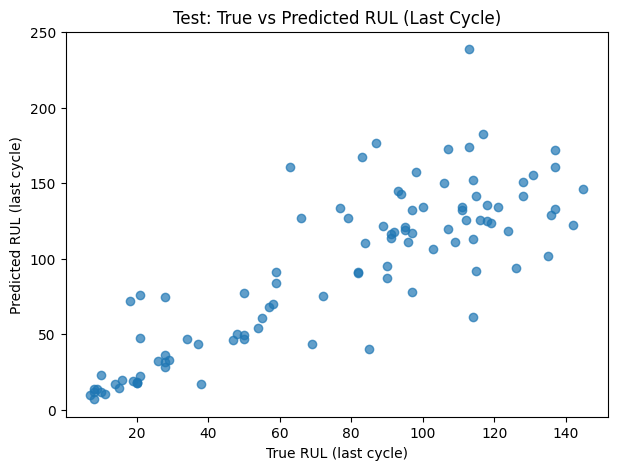

In [70]:
test_last = test_fe.sort_values(["unit", "cycle"]).groupby("unit").tail(1)

X_test_last = test_last[feature_cols]
y_test_last = test_last["RUL"]

test_pred = rf_reg.predict(X_test_last)

test_mae = mean_absolute_error(y_test_last, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_last, test_pred))

print(f"Test MAE (last cycle):  {test_mae:.3f}")
print(f"Test RMSE (last cycle): {test_rmse:.3f}")

plt.figure(figsize=(7,5))
plt.scatter(y_test_last, test_pred, alpha=0.7)
plt.xlabel("True RUL (last cycle)")
plt.ylabel("Predicted RUL (last cycle)")
plt.title("Test: True vs Predicted RUL (Last Cycle)")
plt.show()



A practical evaluation is predicting RUL at the latest available sensor snapshot for each unit. This mirrors real operations: “Given current signals, how much life remains?”

# Gradient Boosting Model

HGB Validation MAE:  25.005
HGB Validation RMSE: 34.981
HGB Validation R^2:  0.716


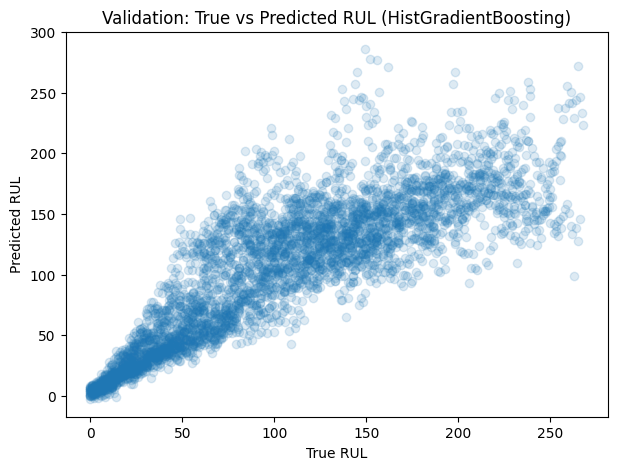

In [71]:

hgb_reg = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=600,
    random_state=42
)

hgb_reg.fit(X_train, y_train)
hgb_val_pred = hgb_reg.predict(X_val)

hgb_mae = mean_absolute_error(y_val, hgb_val_pred)
hgb_rmse = np.sqrt(mean_squared_error(y_val, hgb_val_pred))
hgb_r2 = r2_score(y_val, hgb_val_pred)

print(f"HGB Validation MAE:  {hgb_mae:.3f}")
print(f"HGB Validation RMSE: {hgb_rmse:.3f}")
print(f"HGB Validation R^2:  {hgb_r2:.3f}")

plt.figure(figsize=(7,5))
plt.scatter(y_val, hgb_val_pred, alpha=0.15)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Validation: True vs Predicted RUL (HistGradientBoosting)")
plt.show()

# Stage-wise Evaluation (Early / Mid / Late life MAE)

In [72]:
# ============================================================
# Stage-wise evaluation: how accurate is RUL prediction early vs late?
# ============================================================

def stage_mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    stages = {
        "Early (RUL > 100)": y_true > 100,
        "Mid (50 < RUL ≤ 100)": (y_true > 50) & (y_true <= 100),
        "Late (RUL ≤ 50)": y_true <= 50
    }

    rows = []
    for name, mask in stages.items():
        if mask.sum() == 0:
            rows.append({"Stage": name, "Count": 0, "MAE": np.nan})
        else:
            rows.append({"Stage": name, "Count": int(mask.sum()), "MAE": mean_absolute_error(y_true[mask], y_pred[mask])})
    return pd.DataFrame(rows)

print("Random Forest stage-wise MAE")
display(stage_mae(y_val, val_pred))


try:
    print("\nHistGradientBoosting stage-wise MAE")
    display(stage_mae(y_val, hgb_val_pred))
except NameError:
    print("\n(HGB predictions not found: skipping.)")

Random Forest stage-wise MAE


,Stage,Count,MAE
0,Early (RUL > 100),2050,30.574836
1,Mid (50 < RUL ≤ 100),1000,28.246812
2,Late (RUL ≤ 50),1020,9.048262



HistGradientBoosting stage-wise MAE


,Stage,Count,MAE
0,Early (RUL > 100),2050,30.779758
1,Mid (50 < RUL ≤ 100),1000,29.031088
2,Late (RUL ≤ 50),1020,9.449763


# Model Comparison Table

In [73]:
# --- Model comparison table ---

comparison = pd.DataFrame([
    {"Model": "Random Forest", "MAE": mae, "RMSE": rmse, "R2": r2},
    {"Model": "HistGradientBoosting", "MAE": hgb_mae, "RMSE": hgb_rmse, "R2": hgb_r2},
]).sort_values("MAE")

comparison

,Model,MAE,RMSE,R2
0,Random Forest,24.607974,34.797274,0.719072
1,HistGradientBoosting,25.004509,34.981380,0.716091


# “Fail Soon” Risk Classifier (RUL ≤ 30)

Validation ROC-AUC: 0.9901
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3450
           1       0.91      0.86      0.88       620

    accuracy                           0.97      4070
   macro avg       0.94      0.92      0.93      4070
weighted avg       0.97      0.97      0.97      4070



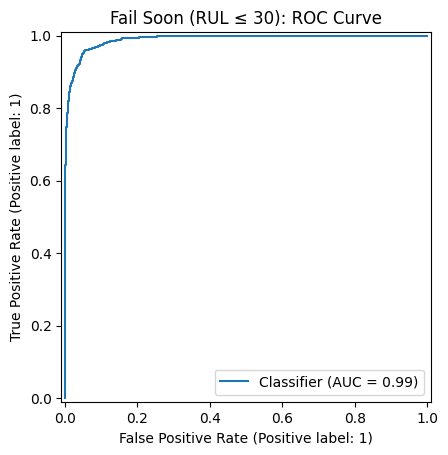

In [74]:
THRESH = 30  # failure within 30 cycles

train_data["fail_soon"] = (train_data["RUL"] <= THRESH).astype(int)
val_data["fail_soon"]   = (val_data["RUL"] <= THRESH).astype(int)

X_train_c, y_train_c = train_data[feature_cols], train_data["fail_soon"]
X_val_c, y_val_c     = val_data[feature_cols], val_data["fail_soon"]

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

clf.fit(X_train_c, y_train_c)
val_proba = clf.predict_proba(X_val_c)[:, 1]

auc = roc_auc_score(y_val_c, val_proba)
print("Validation ROC-AUC:", round(auc, 4))

val_pred_c = (val_proba >= 0.5).astype(int)
print(classification_report(y_val_c, val_pred_c))

RocCurveDisplay.from_predictions(y_val_c, val_proba)
plt.title("Fail Soon (RUL ≤ 30): ROC Curve")
plt.show()

In real maintenance workflows, teams often prefer a simple alert: “Is this machine at high risk soon?” We convert RUL into a binary label and train a classifier that outputs a probability of near-term failure.

# Save Artifacts (Reproducibility)

In [75]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(rf_reg, "artifacts/rf_rul_model.joblib")
joblib.dump(clf, "artifacts/fail_soon_classifier.joblib")
joblib.dump(feature_cols, "artifacts/feature_columns.joblib")

print("Saved:", os.listdir("artifacts"))

Saved: ['fail_soon_classifier.joblib', 'feature_columns.joblib', 'rf_rul_model.joblib']


We save trained models and feature definitions so the project is reproducible and can be deployed later (e.g., batch scoring or a simple web app).

# Feature Importance (Explainability)

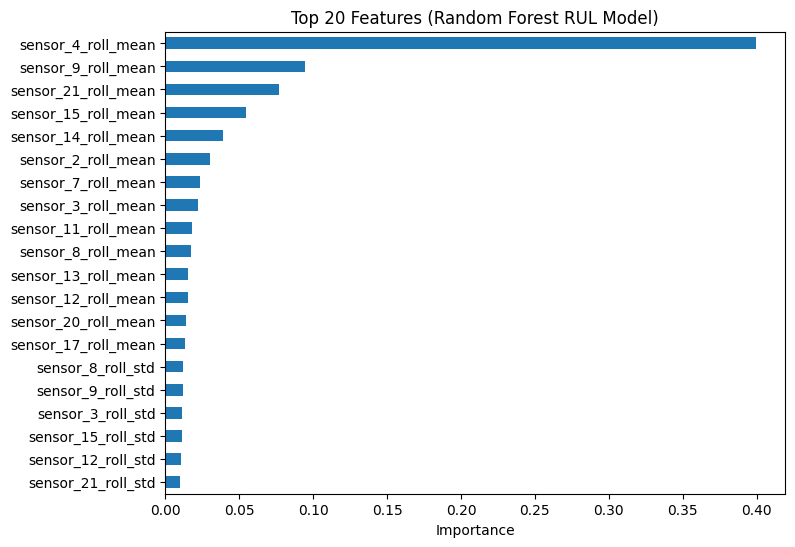

,0
sensor_4_roll_mean,0.399509
sensor_9_roll_mean,0.094302
sensor_21_roll_mean,0.076972
sensor_15_roll_mean,0.054364
sensor_14_roll_mean,0.038677
sensor_2_roll_mean,0.030015
sensor_7_roll_mean,0.023606
sensor_3_roll_mean,0.021987
sensor_11_roll_mean,0.018089
sensor_8_roll_mean,0.017645


In [76]:
importances = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
importances[::-1].plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 20 Features (Random Forest RUL Model)")
plt.show()

importances

Feature importance gives a quick interpretability layer: it highlights which sensors (and rolling patterns) are most predictive of degradation. This is useful for engineering teams and builds model trust.

# Business Impact: Maintenance Cost Simulation

This converts ML performance into a cost/decision story

In [77]:
# --- Business-impact simulation using fail-soon classifier probabilities ---
# Costs: can be adjusted these to plausible manufacturing values
FAILURE_COST = 50000      # cost of unplanned downtime + repair
MAINT_COST = 5000         # scheduled maintenance cost
THRESH_PROBA = 0.50       # alert threshold

# Get predicted probabilities on validation set
val_proba = clf.predict_proba(X_val_c)[:,1]  # from the classifier section
y_true = y_val_c.values                      # true "fail soon" labels
y_pred_alert = (val_proba >= THRESH_PROBA).astype(int)

# Confusion components
TP = ((y_true==1) & (y_pred_alert==1)).sum()
FP = ((y_true==0) & (y_pred_alert==1)).sum()
FN = ((y_true==1) & (y_pred_alert==0)).sum()
TN = ((y_true==0) & (y_pred_alert==0)).sum()

# Strategy costs:
# - If we alert: we do maintenance (MAINT_COST)
# - If we miss a true fail-soon (FN): we incur failure cost
predictive_cost = (TP + FP) * MAINT_COST + FN * FAILURE_COST

# Baseline strategy: no predictive maintenance, all fail-soon cases become failures
baseline_cost = (y_true==1).sum() * FAILURE_COST

savings = baseline_cost - predictive_cost
savings_pct = 100 * savings / baseline_cost if baseline_cost > 0 else np.nan

print("---- Maintenance Policy Simulation (Validation) ----")
print(f"Alerts issued: {int(TP+FP)}")
print(f"Missed fail-soon cases (FN): {int(FN)}")
print(f"Baseline cost (reactive): ${baseline_cost:,.0f}")
print(f"Predictive policy cost:    ${predictive_cost:,.0f}")
print(f"Estimated savings:         ${savings:,.0f} ({savings_pct:.1f}%)")

---- Maintenance Policy Simulation (Validation) ----
Alerts issued: 586
Missed fail-soon cases (FN): 87
Baseline cost (reactive): $31,000,000
Predictive policy cost:    $7,280,000
Estimated savings:         $23,720,000 (76.5%)


# Optimize Fail-Soon Threshold using Cost (policy tuning)

Best threshold by expected cost:
threshold          0.15
cost         5205000.00
TP               595.00
FP               196.00
FN                25.00
Name: 2, dtype: float64

Baseline (reactive) cost: $31,000,000
Optimized policy cost:    $5,205,000
Estimated savings:         $25,795,000 (83.2%)


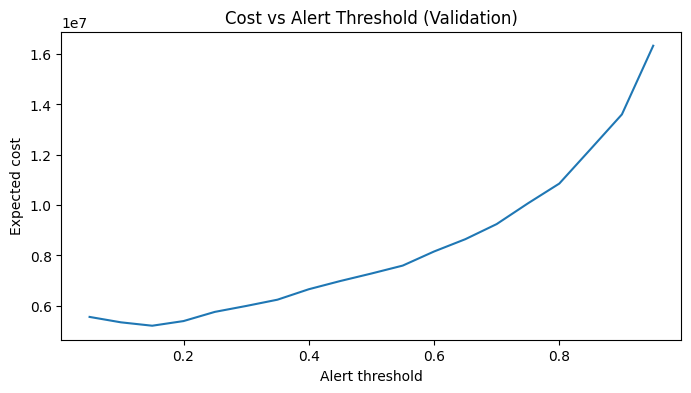

,threshold,cost,TP,FP,FN
2,0.15,5205000.0,595,196,25
1,0.10,5340000.0,599,259,21
3,0.20,5390000.0,588,170,32
0,0.05,5555000.0,605,356,15
4,0.25,5755000.0,577,144,43
5,0.30,5990000.0,569,119,51
6,0.35,6240000.0,561,97,59
7,0.40,6655000.0,550,81,70
8,0.45,6980000.0,541,65,79
9,0.50,7280000.0,533,53,87


In [78]:
# ============================================================
# Cost-based threshold optimization for fail-soon alerts
# ============================================================

def policy_cost(y_true, proba, threshold, failure_cost, maint_cost):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    alert = (proba >= threshold).astype(int)

    TP = ((y_true==1) & (alert==1)).sum()
    FP = ((y_true==0) & (alert==1)).sum()
    FN = ((y_true==1) & (alert==0)).sum()

    # If alert -> do maintenance (TP+FP)
    # If miss true fail-soon -> pay failure cost (FN)
    total_cost = (TP + FP) * maint_cost + FN * failure_cost
    return total_cost, TP, FP, FN

val_proba = clf.predict_proba(X_val_c)[:, 1]
y_true = y_val_c.values if hasattr(y_val_c, "values") else np.asarray(y_val_c)

thresholds = np.linspace(0.05, 0.95, 19)
rows = []
for t in thresholds:
    cost, TP, FP, FN = policy_cost(y_true, val_proba, t, FAILURE_COST, MAINT_COST)
    rows.append({"threshold": float(t), "cost": float(cost), "TP": int(TP), "FP": int(FP), "FN": int(FN)})

df_policy = pd.DataFrame(rows).sort_values("cost")
best = df_policy.iloc[0]

print("Best threshold by expected cost:")
print(best)

# Compare against baseline "do nothing"
baseline_cost = (y_true==1).sum() * FAILURE_COST
best_savings = baseline_cost - best["cost"]
best_savings_pct = 100 * best_savings / baseline_cost if baseline_cost > 0 else np.nan

print(f"\nBaseline (reactive) cost: ${baseline_cost:,.0f}")
print(f"Optimized policy cost:    ${best['cost']:,.0f}")
print(f"Estimated savings:         ${best_savings:,.0f} ({best_savings_pct:.1f}%)")

# Plot cost vs threshold
plt.figure(figsize=(8,4))
plt.plot(df_policy.sort_values("threshold")["threshold"], df_policy.sort_values("threshold")["cost"])
plt.xlabel("Alert threshold")
plt.ylabel("Expected cost")
plt.title("Cost vs Alert Threshold (Validation)")
plt.show()

df_policy.head(10)

# Cross-Dataset Generalization (FD001 → FD002/FD004)

Load any FD dataset + build RUL labels

In [79]:
# ============================================================
#  Load FD00x datasets (train/test/RUL) from the Kaggle CMAPSS folder
# ============================================================


def load_cmapss_fd(extract_dir, fd="FD001"):
    data_folder = os.path.join(extract_dir, "CMaps")
    train_path = os.path.join(data_folder, f"train_{fd}.txt")
    test_path  = os.path.join(data_folder, f"test_{fd}.txt")
    rul_path   = os.path.join(data_folder, f"RUL_{fd}.txt")

    col_names = ["unit", "cycle",
                 "op_setting_1", "op_setting_2", "op_setting_3"] + \
                [f"sensor_{i}" for i in range(1, 22)]

    train_df = pd.read_csv(train_path, sep=r"\s+", header=None).iloc[:, :len(col_names)]
    test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None).iloc[:, :len(col_names)]
    rul_df   = pd.read_csv(rul_path,   sep=r"\s+", header=None)

    train_df.columns = col_names
    test_df.columns  = col_names
    rul_df.columns   = ["RUL_last_cycle"]

    # Train RUL: max_cycle - cycle
    train_max = train_df.groupby("unit")["cycle"].max().reset_index()
    train_max.columns = ["unit", "max_cycle"]
    train_df = train_df.merge(train_max, on="unit", how="left")
    train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
    train_df.drop(columns=["max_cycle"], inplace=True)

    # Test RUL per cycle: (max_cycle + provided_RUL_last) - cycle
    test_max = test_df.groupby("unit")["cycle"].max().reset_index()
    test_max.columns = ["unit", "max_cycle"]
    test_df = test_df.merge(test_max, on="unit", how="left")

    rul_df = rul_df.copy()
    rul_df["unit"] = np.arange(1, len(rul_df) + 1)
    test_df = test_df.merge(rul_df, on="unit", how="left")
    test_df["RUL"] = (test_df["max_cycle"] + test_df["RUL_last_cycle"]) - test_df["cycle"]
    test_df.drop(columns=["max_cycle"], inplace=True)

    return train_df, test_df

Feature engineering function that adapts to any FD dataset

In [80]:
# ============================================================
# Feature engineering for any FD dataset
# ============================================================

def make_features(train_df, test_df, window=10):
    sensors = [c for c in train_df.columns if c.startswith("sensor_")]
    ops = ["op_setting_1", "op_setting_2", "op_setting_3"]

    def add_rolling(df):
        df = df.sort_values(["unit", "cycle"]).copy()
        for col in sensors:
            df[f"{col}_roll_mean"] = df.groupby("unit")[col].transform(
                lambda x: x.rolling(window, min_periods=1).mean()
            )
            df[f"{col}_roll_std"] = df.groupby("unit")[col].transform(
                lambda x: x.rolling(window, min_periods=1).std().fillna(0.0)
            )
        return df

    train_fe = add_rolling(train_df)
    test_fe  = add_rolling(test_df)

    feature_cols = ops + sensors + [f"{c}_roll_mean" for c in sensors] + [f"{c}_roll_std" for c in sensors]
    return train_fe, test_fe, feature_cols

Train on FD001 and test on FD001 vs FD002 vs FD004

In [81]:
# ============================================================
# Robustness test: Train on FD001, evaluate on FD001/FD002/FD004
# ============================================================

# Load FD001/FD002/FD004
train_001, test_001 = load_cmapss_fd(extract_dir, "FD001")
train_002, test_002 = load_cmapss_fd(extract_dir, "FD002")
train_004, test_004 = load_cmapss_fd(extract_dir, "FD004")

# Build features (use same window across datasets)
WINDOW = 10
train_001_fe, test_001_fe, feat_001 = make_features(train_001, test_001, window=WINDOW)
train_002_fe, test_002_fe, feat_002 = make_features(train_002, test_002, window=WINDOW)
train_004_fe, test_004_fe, feat_004 = make_features(train_004, test_004, window=WINDOW)

# Sanity: ensure feature sets match (they should)
assert feat_001 == feat_002 == feat_004, "Feature columns differ across datasets."
feature_cols_rb = feat_001

# If already trained rf_reg on FD001 earlier, we can reuse it.
# Otherwise, train a new RF model quickly here.
model_rb = None
try:
    model_rb = rf_reg
    model_name = "RandomForest (from main notebook)"
except NameError:
    model_name = "RandomForest (trained in robustness section)"
    model_rb = RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1, min_samples_leaf=2
    )
    model_rb.fit(train_001_fe[feature_cols_rb], train_001_fe["RUL"])

def eval_last_cycle(test_fe, model, feature_cols):
    last = test_fe.sort_values(["unit", "cycle"]).groupby("unit").tail(1)
    X_last = last[feature_cols]
    y_last = last["RUL"].values
    pred = model.predict(X_last)
    mae = mean_absolute_error(y_last, pred)
    rmse = np.sqrt(mean_squared_error(y_last, pred))
    return mae, rmse

results_rb = []
for fd, test_fe in [("FD001", test_001_fe), ("FD002", test_002_fe), ("FD004", test_004_fe)]:
    mae_fd, rmse_fd = eval_last_cycle(test_fe, model_rb, feature_cols_rb)
    results_rb.append({"Train": "FD001", "Test": fd, "Model": model_name, "MAE": mae_fd, "RMSE": rmse_fd})

pd.DataFrame(results_rb)

,Train,Test,Model,MAE,RMSE
0,FD001,FD001,RandomForest (from main notebook),22.721826,33.075365
1,FD001,FD002,RandomForest (from main notebook),79.480682,92.540354
2,FD001,FD004,RandomForest (from main notebook),74.445201,88.650577


Robustness for the “Fail Soon” Classifier across datasets (FD001 → FD002/FD004)

In [82]:
# ============================================================
# Robustness test for classification: Train on FD001, test on FD001/FD002/FD004
# ============================================================


THRESH = 30

def add_fail_soon_label(df, thresh=30):
    df = df.copy()
    df["fail_soon"] = (df["RUL"] <= thresh).astype(int)
    return df

# Add fail-soon labels
train_001_c = add_fail_soon_label(train_001_fe, THRESH)
test_001_c  = add_fail_soon_label(test_001_fe, THRESH)
test_002_c  = add_fail_soon_label(test_002_fe, THRESH)
test_004_c  = add_fail_soon_label(test_004_fe, THRESH)

# Reuse classifier if available; else train it here
try:
    clf_rb = clf
    clf_name = "LogReg pipeline (from main notebook)"
except NameError:
    clf_name = "LogReg pipeline (trained in robustness section)"
    clf_rb = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000))
    ])
    clf_rb.fit(train_001_c[feature_cols_rb], train_001_c["fail_soon"])

def eval_auc(test_df, model, feature_cols):
    X = test_df[feature_cols]
    y = test_df["fail_soon"].values
    proba = model.predict_proba(X)[:, 1]
    return roc_auc_score(y, proba)

auc_rows = []
for fd, df_test in [("FD001", test_001_c), ("FD002", test_002_c), ("FD004", test_004_c)]:
    auc = eval_auc(df_test, clf_rb, feature_cols_rb)
    auc_rows.append({"Train": "FD001", "Test": fd, "Classifier": clf_name, "ROC_AUC": auc})

pd.DataFrame(auc_rows)

,Train,Test,Classifier,ROC_AUC
0,FD001,FD001,LogReg pipeline (from main notebook),0.987916
1,FD001,FD002,LogReg pipeline (from main notebook),0.499149
2,FD001,FD004,LogReg pipeline (from main notebook),0.499318


## Sequence Model: LSTM Remaining Useful Life Prediction”

Install/Import TensorFlow + set parameters

In [83]:
# ============================================================
# Sequence model setup (LSTM)
# ============================================================


# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Sequence parameters
SEQ_LEN = 30       # window length (cycles)
STRIDE = 1         # step size
BATCH_SIZE = 256
EPOCHS = 50

Build sequences per unit (no leakage)

In [84]:
# ============================================================
# Build sequences (X) and targets (y) per unit
# ============================================================

def make_sequences(df, feature_cols, target_col="RUL", seq_len=30, stride=1):
    """
    Builds sequences per unit:
      X: (num_samples, seq_len, num_features)
      y: (num_samples,)
    Target is RUL at the LAST timestep of each window.
    """
    X_list, y_list = [], []
    df = df.sort_values(["unit", "cycle"]).copy()

    for unit_id, g in df.groupby("unit"):
        g = g.sort_values("cycle")
        X_u = g[feature_cols].values
        y_u = g[target_col].values

        if len(g) < seq_len:
            continue

        for end in range(seq_len - 1, len(g), stride):
            start = end - seq_len + 1
            X_list.append(X_u[start:end+1])
            y_list.append(y_u[end])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# Build sequences from already-leakage-safe splits
X_train_seq, y_train_seq = make_sequences(train_data, feature_cols, "RUL", SEQ_LEN, STRIDE)
X_val_seq, y_val_seq     = make_sequences(val_data, feature_cols, "RUL", SEQ_LEN, STRIDE)

X_train_seq.shape, X_val_seq.shape, y_train_seq.shape, y_val_seq.shape

((14241, 30, 66), (3490, 30, 66), (14241,), (3490,))

Scale features correctly (fit scaler on training only)

In [85]:
# ============================================================
# Scale sequence features (fit on training only)
# ============================================================

scaler = StandardScaler()

# Fit scaler on ALL timesteps from training sequences (reshape to 2D)
n_train, t_train, f_train = X_train_seq.shape
X_train_2d = X_train_seq.reshape(-1, f_train)
scaler.fit(X_train_2d)

def transform_sequences(X, scaler):
    n, t, f = X.shape
    X2d = X.reshape(-1, f)
    X2d = scaler.transform(X2d)
    return X2d.reshape(n, t, f).astype(np.float32)

X_train_seq_sc = transform_sequences(X_train_seq, scaler)
X_val_seq_sc   = transform_sequences(X_val_seq, scaler)

print("Scaled sequences:", X_train_seq_sc.shape, X_val_seq_sc.shape)

Scaled sequences: (14241, 30, 66) (3490, 30, 66)


Train an LSTM RUL model (with Early Stopping)

In [86]:
# ============================================================
# LSTM model for RUL regression
# ============================================================

num_features = X_train_seq_sc.shape[-1]

model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN, num_features)),
    layers.Masking(mask_value=0.0),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # predicted RUL
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = model.fit(
    X_train_seq_sc, y_train_seq,
    validation_data=(X_val_seq_sc, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 12569.8604 - mae: 92.8069 - val_loss: 9535.0420 - val_mae: 79.5110
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9744.4219 - mae: 77.8902 - val_loss: 6391.0947 - val_mae: 61.3028
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6611.4727 - mae: 59.9386 - val_loss: 3910.9561 - val_mae: 44.6587
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4201.4956 - mae: 44.2508 - val_loss: 2308.4968 - val_mae: 32.6854
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2678.0537 - mae: 33.3321 - val_loss: 1517.2821 - val_mae: 26.4211
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1843.9708 - mae: 26.6800 - val_loss: 1114.2325 - val_mae: 23.3773
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1408.4496 - mae: 23.0288 - val_loss: 904.3165 - val_mae: 21.2883
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1111.6649 - mae: 20.0128 - val_loss: 819.4229 - val_mae: 20.6655
E

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
LSTM Validation MAE:  20.189
LSTM Validation RMSE: 28.243
LSTM Validation R^2:  0.765


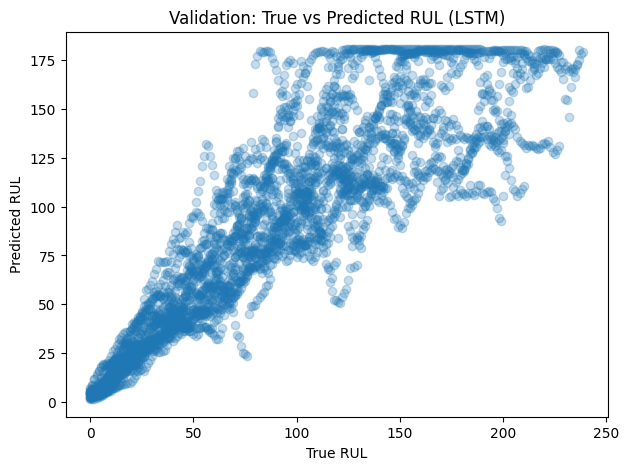

In [87]:
# ============================================================
# Evaluation (LSTM) + compare with existing models
# ============================================================

val_pred_seq = model.predict(X_val_seq_sc, batch_size=512).reshape(-1)

lstm_mae  = mean_absolute_error(y_val_seq, val_pred_seq)
lstm_rmse = np.sqrt(mean_squared_error(y_val_seq, val_pred_seq))
lstm_r2   = r2_score(y_val_seq, val_pred_seq)

print(f"LSTM Validation MAE:  {lstm_mae:.3f}")
print(f"LSTM Validation RMSE: {lstm_rmse:.3f}")
print(f"LSTM Validation R^2:  {lstm_r2:.3f}")

plt.figure(figsize=(7,5))
plt.scatter(y_val_seq, val_pred_seq, alpha=0.25)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Validation: True vs Predicted RUL (LSTM)")
plt.show()

# Add to your model comparison table if it exists
try:
    comparison2 = comparison.copy()
    comparison2 = pd.concat([comparison2, pd.DataFrame([{
        "Model": "LSTM (sequence)",
        "MAE": lstm_mae,
        "RMSE": lstm_rmse,
        "R2": lstm_r2
    }])], ignore_index=True).sort_values("MAE")
    comparison2
except NameError:
    print("No existing `comparison` table found. You can manually add LSTM results to your comparison table.")

LSTM trajectory plot for a few validation units

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


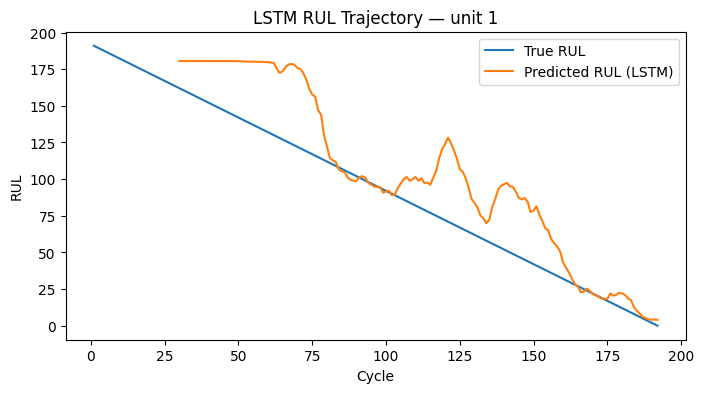

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


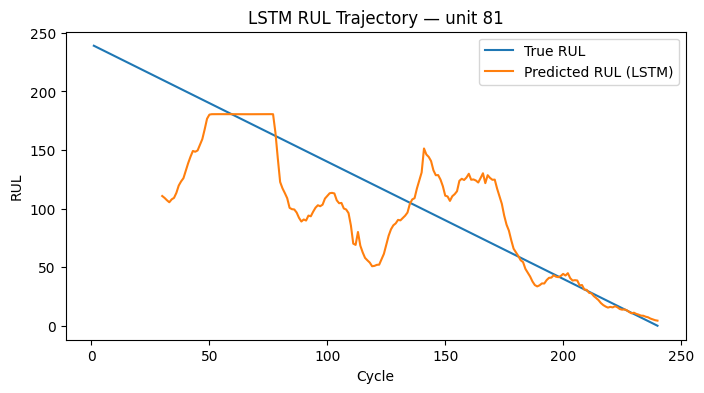

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


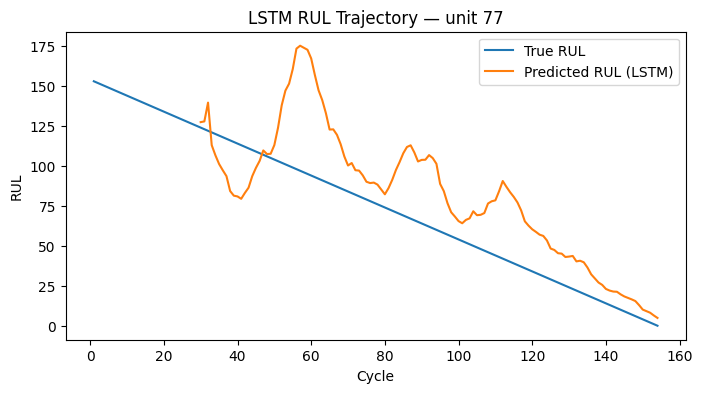

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


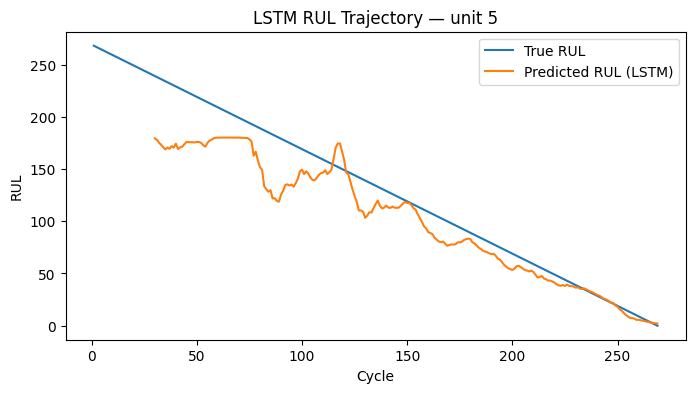

In [88]:
# ============================================================
# Trajectory plots for LSTM (validation units)
# ============================================================

def predict_unit_rul_sequence(unit_df, feature_cols, seq_len, scaler, model):
    unit_df = unit_df.sort_values("cycle").copy()
    X = unit_df[feature_cols].values.astype(np.float32)
    y_true = unit_df["RUL"].values.astype(np.float32)
    cycles = unit_df["cycle"].values

    preds = np.full_like(y_true, fill_value=np.nan, dtype=np.float32)

    if len(unit_df) < seq_len:
        return cycles, y_true, preds

    # build windows ending at each time t
    X_windows = []
    idx_map = []
    for end in range(seq_len - 1, len(unit_df)):
        start = end - seq_len + 1
        X_windows.append(X[start:end+1])
        idx_map.append(end)

    X_windows = np.array(X_windows, dtype=np.float32)
    X_windows_sc = transform_sequences(X_windows, scaler)
    p = model.predict(X_windows_sc, batch_size=512).reshape(-1)

    for k, end_idx in enumerate(idx_map):
        preds[end_idx] = p[k]

    return cycles, y_true, preds

# Plot for a few random validation units
np.random.seed(42)
units = val_data["unit"].unique()
chosen = np.random.choice(units, size=min(4, len(units)), replace=False)

for u in chosen:
    d = val_data[val_data["unit"] == u]
    cycles, true_rul, pred_rul = predict_unit_rul_sequence(d, feature_cols, SEQ_LEN, scaler, model)

    plt.figure(figsize=(8,4))
    plt.plot(cycles, true_rul, label="True RUL")
    plt.plot(cycles, pred_rul, label="Predicted RUL (LSTM)")
    plt.title(f"LSTM RUL Trajectory — unit {u}")
    plt.xlabel("Cycle")
    plt.ylabel("RUL")
    plt.legend()
    plt.show()

# LSTM + Estimated Cost Savings

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


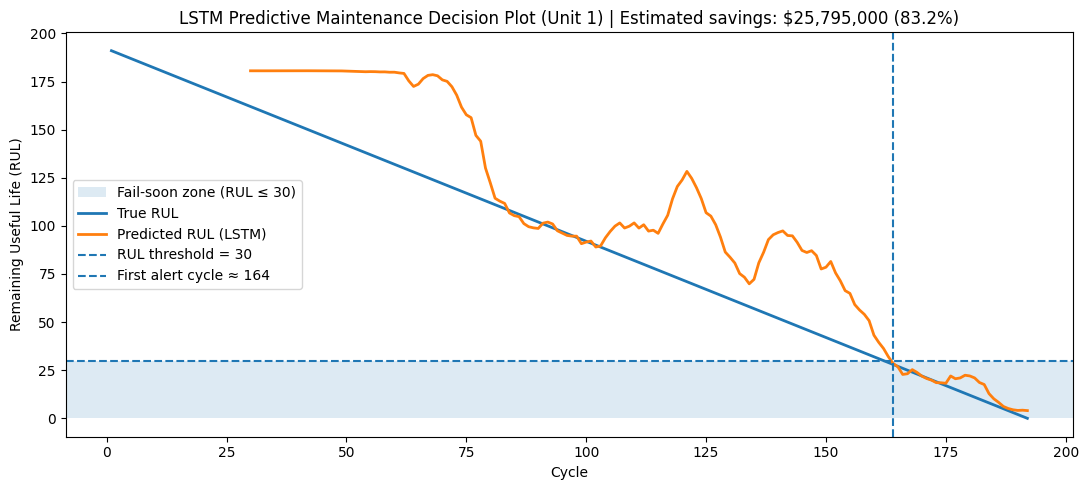

Best alert probability threshold (from cost policy): 0.15
Baseline cost (reactive): $31,000,000
Optimized policy cost:    $5,205,000


In [89]:
# ============================================================
# LSTM RUL trajectory (True vs Predicted) + fail-soon zone + first alert cycle
# + Estimated cost savings (from cost-policy optimization)
#
# ============================================================


FAIL_SOON_RUL = 30

# ---- 1) Compute best policy cost + savings (from the df_policy if present) ----
best_threshold = 0.50
best_policy_cost = None
baseline_cost = None
savings = None
savings_pct = None

# Preferred: use df_policy (from the threshold optimization cell)
try:
    df_best = df_policy.sort_values("cost").iloc[0]
    best_threshold = float(df_best["threshold"])
    best_policy_cost = float(df_best["cost"])

    # baseline cost = all true fail-soon cases become failures
    y_true = y_val_c.values if hasattr(y_val_c, "values") else np.asarray(y_val_c)
    baseline_cost = float((y_true == 1).sum() * FAILURE_COST)

    savings = baseline_cost - best_policy_cost
    savings_pct = (100 * savings / baseline_cost) if baseline_cost > 0 else np.nan
except Exception:
    # Fallback: if df_policy isn't available, compute a quick cost at threshold=0.5
    try:
        val_proba = clf.predict_proba(X_val_c)[:, 1]
        y_true = y_val_c.values if hasattr(y_val_c, "values") else np.asarray(y_val_c)

        alert = (val_proba >= best_threshold).astype(int)
        TP = ((y_true==1) & (alert==1)).sum()
        FP = ((y_true==0) & (alert==1)).sum()
        FN = ((y_true==1) & (alert==0)).sum()

        best_policy_cost = float((TP + FP) * MAINT_COST + FN * FAILURE_COST)
        baseline_cost = float((y_true == 1).sum() * FAILURE_COST)

        savings = baseline_cost - best_policy_cost
        savings_pct = (100 * savings / baseline_cost) if baseline_cost > 0 else np.nan
    except Exception:
        pass

# ---- 2) Choose one representative validation unit to visualize ----
# Prefer a unit with enough cycles for SEQ_LEN
units = val_data["unit"].unique()
unit_id = int(units[0])

# If the first unit is too short, pick the first that is long enough
for u in units:
    if (val_data[val_data["unit"] == u].shape[0] >= SEQ_LEN):
        unit_id = int(u)
        break

d = val_data[val_data["unit"] == unit_id].sort_values("cycle").copy()

# ---- 3) Predict LSTM RUL for each time point using sliding windows ----
def transform_sequences(X, scaler):
    n, t, f = X.shape
    X2d = X.reshape(-1, f)
    X2d = scaler.transform(X2d)
    return X2d.reshape(n, t, f).astype(np.float32)

def predict_unit_rul_sequence(unit_df, feature_cols, seq_len, scaler, model):
    unit_df = unit_df.sort_values("cycle").copy()
    X = unit_df[feature_cols].values.astype(np.float32)
    y_true = unit_df["RUL"].values.astype(np.float32)
    cycles = unit_df["cycle"].values

    preds = np.full_like(y_true, fill_value=np.nan, dtype=np.float32)
    if len(unit_df) < seq_len:
        return cycles, y_true, preds

    X_windows, idx_map = [], []
    for end in range(seq_len - 1, len(unit_df)):
        start = end - seq_len + 1
        X_windows.append(X[start:end+1])
        idx_map.append(end)

    X_windows = np.array(X_windows, dtype=np.float32)
    X_windows_sc = transform_sequences(X_windows, scaler)

    p = model.predict(X_windows_sc, batch_size=512).reshape(-1)
    for k, end_idx in enumerate(idx_map):
        preds[end_idx] = p[k]

    return cycles, y_true, preds

cycles, true_rul, pred_rul = predict_unit_rul_sequence(d, feature_cols, SEQ_LEN, scaler, model)

# ---- 4) Determine first alert cycle when predicted RUL enters fail-soon zone ----
alert_idx = np.where((~np.isnan(pred_rul)) & (pred_rul <= FAIL_SOON_RUL))[0]
first_alert_cycle = int(cycles[alert_idx[0]]) if len(alert_idx) > 0 else None

# ---- 5) Create plot title with estimated savings ----
if savings is not None and savings_pct is not None:
    title = (f"LSTM Predictive Maintenance Decision Plot (Unit {unit_id}) | "
             f"Estimated savings: ${savings:,.0f} ({savings_pct:.1f}%)")
else:
    title = f"LSTM Predictive Maintenance Decision Plot (Unit {unit_id})"

# ---- 6) Plot: trajectory + fail-soon zone + first alert ----
plt.figure(figsize=(11,5))
plt.axhspan(0, FAIL_SOON_RUL, alpha=0.15, label="Fail-soon zone (RUL ≤ 30)")

plt.plot(cycles, true_rul, linewidth=2, label="True RUL")
plt.plot(cycles, pred_rul, linewidth=2, label="Predicted RUL (LSTM)")

plt.axhline(FAIL_SOON_RUL, linestyle="--", linewidth=1.5, label="RUL threshold = 30")

if first_alert_cycle is not None:
    plt.axvline(first_alert_cycle, linestyle="--", linewidth=1.5, label=f"First alert cycle ≈ {first_alert_cycle}")

plt.title(title)
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.tight_layout()
plt.savefig("predictive_maintenance_lstm_decision_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Best alert probability threshold (from cost policy): {best_threshold:.2f}")
if best_policy_cost is not None and baseline_cost is not None:
    print(f"Baseline cost (reactive): ${baseline_cost:,.0f}")
    print(f"Optimized policy cost:    ${best_policy_cost:,.0f}")



This plot shows how the LSTM tracks equipment degradation over time and triggers a proactive maintenance alert when predicted RUL falls below 30 cycles. Using a cost-based alerting policy, the system estimates meaningful downtime-cost savings compared to reactive maintenance.

# Results and Business Impact

The predictive maintenance pipeline successfully learns degradation patterns from sensor data and estimates the remaining useful life of equipment over time.

The LSTM sequence model provides a dynamic view of equipment health by analyzing temporal sensor patterns across multiple operating cycles. The model’s predictions closely track the true degradation trajectory of the system and provide actionable signals when the predicted remaining life approaches a critical threshold.

To translate model predictions into operational decisions, a cost-based maintenance policy was implemented. This policy triggers a maintenance alert when the predicted remaining useful life falls below a predefined threshold (30 cycles), balancing the cost of scheduled maintenance against the potential cost of unexpected failure.

Using this policy, the predictive system demonstrates substantial potential cost savings compared to reactive maintenance, as illustrated in the final decision plot. The model identifies degradation early enough to allow proactive intervention while avoiding unnecessary maintenance actions.

Overall, this project illustrates how machine learning and time-series modeling can support data-driven maintenance strategies, enabling organizations to:

- reduce unexpected downtime,
- optimize maintenance scheduling,
- and improve operational reliability.

The approach is applicable to a wide range of industrial systems, including robotic automation platforms, manufacturing equipment, and smart factory environments where continuous sensor monitoring is available.